In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 1. read csv
df = pd.read_csv("iris_unlabaled.csv")

df

,Unnamed: 0,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,0,5.1,3.5,1.4,0.2,0
1,1,4.9,3.0,1.4,0.2,0
2,2,4.7,3.2,1.3,0.2,0
3,3,4.6,3.1,1.5,0.2,0
4,4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,145,6.7,3.0,5.2,2.3,2
146,146,6.3,2.5,5.0,1.9,2
147,147,6.5,3.0,5.2,2.0,2
148,148,6.2,3.4,5.4,2.3,2


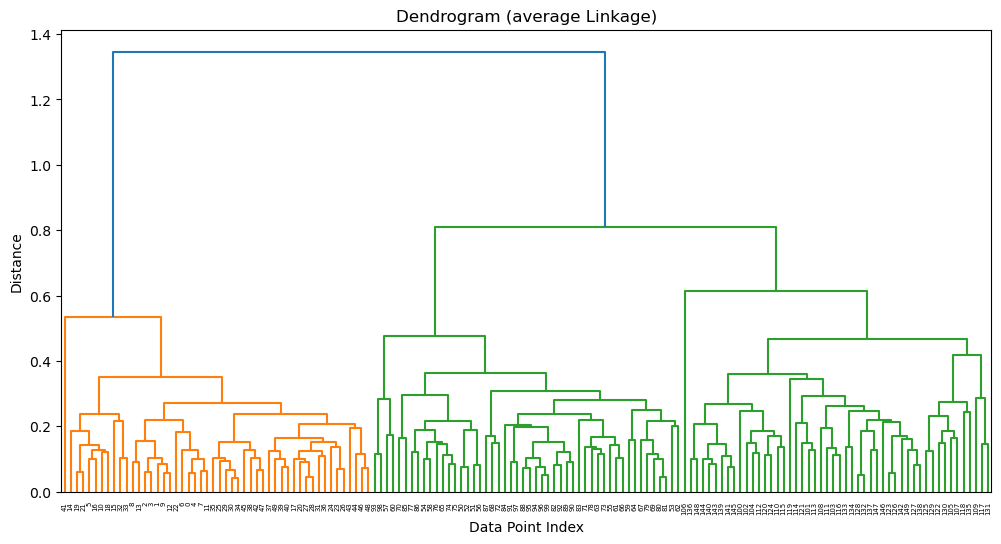

cluster
1    49
2     1
3     4
4    46
5    49
6     1
Name: count, dtype: int64


0      1
1      1
2      1
3      1
4      1
      ..
145    5
146    5
147    5
148    5
149    5
Name: cluster, Length: 150, dtype: int32

In [2]:
# 2. choose numeric columns
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# 3. MinMaxScaler
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

# 4. ward
linkage_matrix = linkage(df_scaled, method='average')

# 5. draw 
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title("Dendrogram (average Linkage)")
plt.xlabel("Data Point Index")
plt.ylabel("Distance")
plt.show()

# 6. Cut the tree into 3 clusters and get labels (1..3)
# This will now work perfectly!
cluster_labels = fcluster(linkage_matrix, t=6, criterion='maxclust')

# 7. Attach labels back to the (scaled or original) dataframe
df['cluster'] = cluster_labels  # or df_scaled['cluster'] = cluster_labels

# (Optional) quick peek at counts
print(df['cluster'].value_counts().sort_index())
df['cluster']